In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


data = pd.read_csv("Student Performance new.csv")
data=pd.DataFrame(data)
data

,Unnamed: 0,race/ethnicity,parental level of education,lunch,test preparation course,math percentage,reading score percentage,writing score percentage,sex
0,0,group B,bachelor's degree,standard,none,0.72,0.72,0.74,F
1,1,group C,some college,standard,completed,0.69,0.90,0.88,F
2,2,group B,master's degree,standard,none,0.90,0.95,0.93,F
3,3,group A,associate's degree,free/reduced,none,0.47,0.57,0.44,M
4,4,group C,some college,standard,none,0.76,0.78,0.75,M
...,...,...,...,...,...,...,...,...,...
995,995,group E,master's degree,standard,completed,0.88,0.99,0.95,F
996,996,group C,high school,free/reduced,none,0.62,0.55,0.55,M
997,997,group C,high school,free/reduced,completed,0.59,0.71,0.65,F
998,998,group D,some college,standard,completed,0.68,0.78,0.77,F


In [2]:
!pip install scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
print(data)

     Unnamed: 0 race/ethnicity parental level of education         lunch  \
0             0        group B           bachelor's degree      standard   
1             1        group C                some college      standard   
2             2        group B             master's degree      standard   
3             3        group A          associate's degree  free/reduced   
4             4        group C                some college      standard   
..          ...            ...                         ...           ...   
995         995        group E             master's degree      standard   
996         996        group C                 high school  free/reduced   
997         997        group C                 high school  free/reduced   
998         998        group D                some college      standard   
999         999        group D                some college  free/reduced   

    test preparation course  math percentage  reading score percentage  \
0            

In [4]:
data.head()


,Unnamed: 0,race/ethnicity,parental level of education,lunch,test preparation course,math percentage,reading score percentage,writing score percentage,sex
0,0,group B,bachelor's degree,standard,none,0.72,0.72,0.74,F
1,1,group C,some college,standard,completed,0.69,0.90,0.88,F
2,2,group B,master's degree,standard,none,0.90,0.95,0.93,F
3,3,group A,associate's degree,free/reduced,none,0.47,0.57,0.44,M
4,4,group C,some college,standard,none,0.76,0.78,0.75,M


In [5]:
data.tail()


,Unnamed: 0,race/ethnicity,parental level of education,lunch,test preparation course,math percentage,reading score percentage,writing score percentage,sex
995,995,group E,master's degree,standard,completed,0.88,0.99,0.95,F
996,996,group C,high school,free/reduced,none,0.62,0.55,0.55,M
997,997,group C,high school,free/reduced,completed,0.59,0.71,0.65,F
998,998,group D,some college,standard,completed,0.68,0.78,0.77,F
999,999,group D,some college,free/reduced,none,0.77,0.86,0.86,F


In [6]:
data.dtypes

Unnamed: 0                       int64
race/ethnicity                  object
parental level of education     object
lunch                           object
test preparation course         object
math percentage                float64
reading score percentage       float64
writing score percentage       float64
sex                             object
dtype: object

In [7]:
data.sample()

,Unnamed: 0,race/ethnicity,parental level of education,lunch,test preparation course,math percentage,reading score percentage,writing score percentage,sex
759,759,group B,some college,standard,completed,0.69,0.77,0.77,M


In [8]:
data.shape #rows , columns

(1000, 9)

In [9]:
data.info() #number el fihom data = not null


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   1000 non-null   int64  
 1   race/ethnicity               1000 non-null   object 
 2   parental level of education  1000 non-null   object 
 3   lunch                        1000 non-null   object 
 4   test preparation course      1000 non-null   object 
 5   math percentage              1000 non-null   float64
 6   reading score percentage     1000 non-null   float64
 7   writing score percentage     1000 non-null   float64
 8   sex                          1000 non-null   object 
dtypes: float64(3), int64(1), object(5)
memory usage: 70.4+ KB


In [10]:
data.describe()


,Unnamed: 0,math percentage,reading score percentage,writing score percentage
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,0.660890,0.691690,0.680540
std,288.819436,0.151631,0.146002,0.151957
min,0.000000,0.000000,0.170000,0.100000
25%,249.750000,0.570000,0.590000,0.577500
50%,499.500000,0.660000,0.700000,0.690000
75%,749.250000,0.770000,0.790000,0.790000
max,999.000000,1.000000,1.000000,1.000000


In [11]:
data.describe(include="object")

,race/ethnicity,parental level of education,lunch,test preparation course,sex
count,1000,1000,1000,1000,1000
unique,5,6,2,2,2
top,group C,some college,standard,none,F
freq,319,226,645,642,518


In [12]:
data.columns


Index(['Unnamed: 0', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math percentage',
       'reading score percentage', 'writing score percentage', 'sex'],
      dtype='object')

In [13]:
data.isna()

,Unnamed: 0,race/ethnicity,parental level of education,lunch,test preparation course,math percentage,reading score percentage,writing score percentage,sex
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False,False
996,False,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False,False


In [14]:
data.isna().sum()

Unnamed: 0                     0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math percentage                0
reading score percentage       0
writing score percentage       0
sex                            0
dtype: int64

In [15]:
data.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool

In [16]:
data.duplicated().sum()

np.int64(0)

In [17]:
data.drop(columns=['Unnamed: 0' ], inplace = True)
data.head(10)

,race/ethnicity,parental level of education,lunch,test preparation course,math percentage,reading score percentage,writing score percentage,sex
0,group B,bachelor's degree,standard,none,0.72,0.72,0.74,F
1,group C,some college,standard,completed,0.69,0.90,0.88,F
2,group B,master's degree,standard,none,0.90,0.95,0.93,F
3,group A,associate's degree,free/reduced,none,0.47,0.57,0.44,M
4,group C,some college,standard,none,0.76,0.78,0.75,M
5,group B,associate's degree,standard,none,0.71,0.83,0.78,F
6,group B,some college,standard,completed,0.88,0.95,0.92,F
7,group B,some college,free/reduced,none,0.40,0.43,0.39,M
8,group D,high school,free/reduced,completed,0.64,0.64,0.67,M
9,group B,high school,free/reduced,none,0.38,0.60,0.50,F


In [18]:
print(data["test preparation course"].value_counts())

test preparation course
none         642
completed    358
Name: count, dtype: int64


In [19]:
for i in data.columns :
    if data[i].dtype == object:
        print("Column Name:", i)
        print(data[i].unique())
        print(data[i].nunique())
        print(data[i].value_counts())
        print("_"*91)


Column Name: race/ethnicity
['group B' 'group C' 'group A' 'group D' 'group E']
5
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64
___________________________________________________________________________________________
Column Name: parental level of education
["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
6
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64
___________________________________________________________________________________________
Column Name: lunch
['standard' 'free/reduced']
2
lunch
standard        645
free/reduced    355
Name: count, dtype: int64
___________________________________________________________________________________________
Column Name: test preparation course
['non

In [20]:
num_col = data.select_dtypes(include =['float','int'])
for i in num_col:
    Q1 = data[i].quantile(0.25)
    Q3 = data[i].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier = data[(data[i] < lower) | (data[i] > upper)] #search + print outliers
    print(outlier)
    data = data[(data[i] >= lower) & (data[i] <= upper)] #bei4el el outlier
print(data)


    race/ethnicity parental level of education         lunch  \
17         group B            some high school  free/reduced   
59         group C            some high school  free/reduced   
145        group C                some college  free/reduced   
338        group B            some high school  free/reduced   
466        group D          associate's degree  free/reduced   
787        group B                some college      standard   
842        group B                 high school  free/reduced   
980        group B                 high school  free/reduced   

    test preparation course  math percentage  reading score percentage  \
17                     none             0.18                      0.32   
59                     none             0.00                      0.17   
145                    none             0.22                      0.39   
338                    none             0.24                      0.38   
466                    none             0.26         

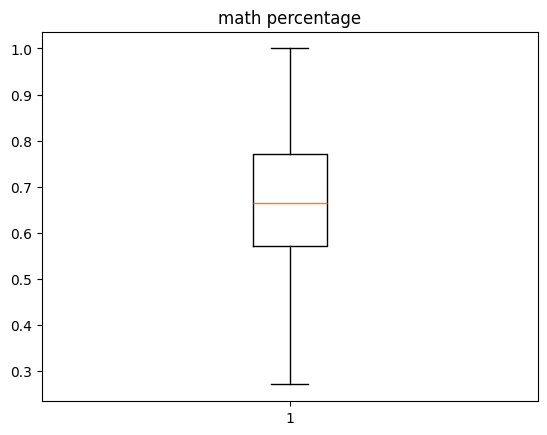

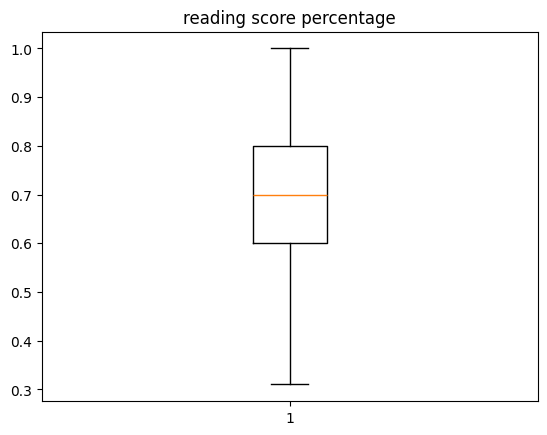

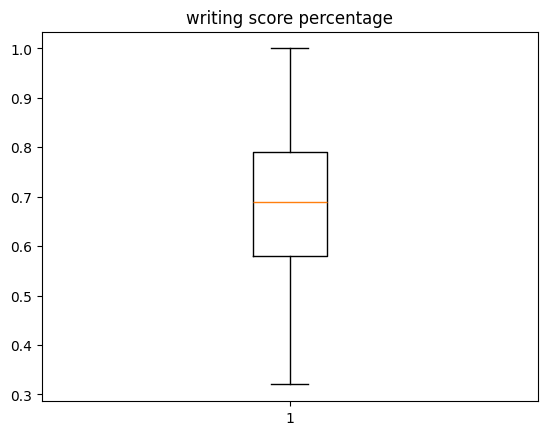

In [21]:
#num_col = data.select_dtypes(include=['float','int'])

for col in num_col:
    plt.figure()
    plt.boxplot(data[col])
    plt.title(col)
    plt.show()

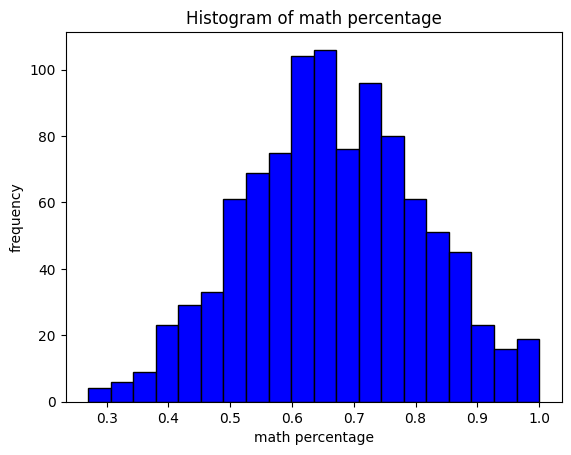

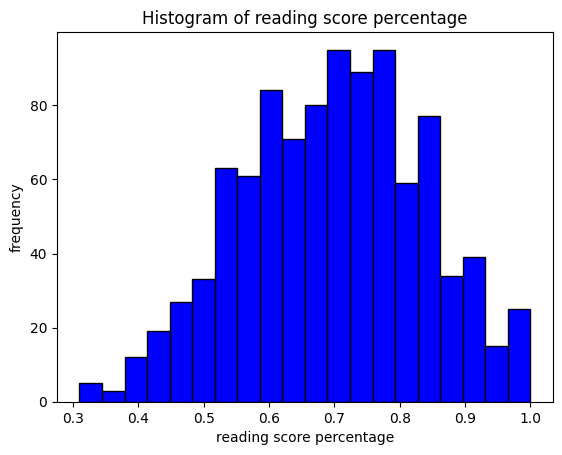

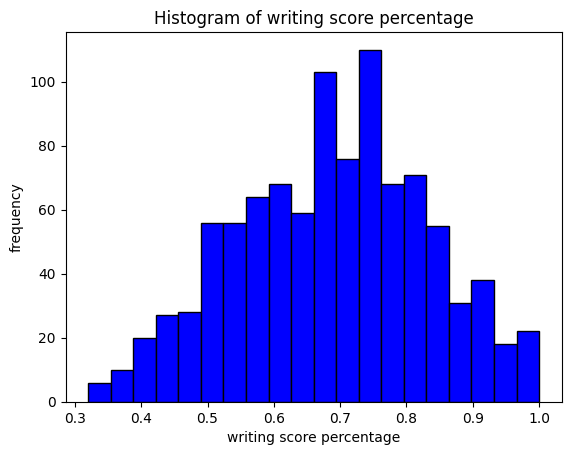

In [22]:
# =data.select_dtypes(include =['float','int'])

for i in num_col:
    plt.hist(data[i] ,color = 'blue' ,edgecolor='black' , bins = 20 )
    plt.xlabel(data[i].name)
    plt.ylabel('frequency')
    plt.title("Histogram of " + i)
    plt.show()

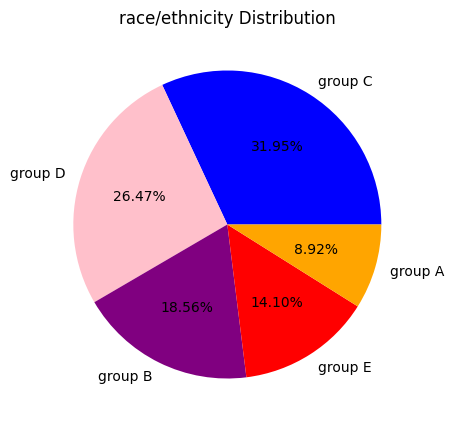

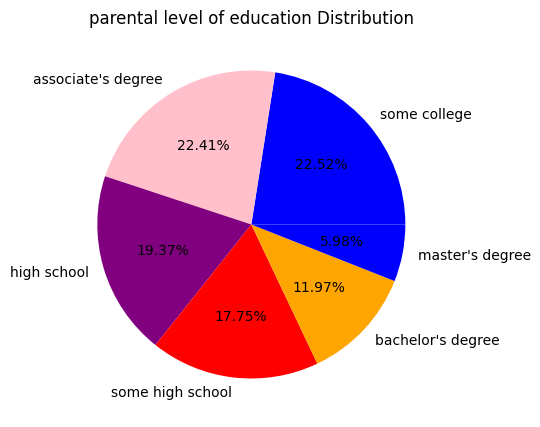

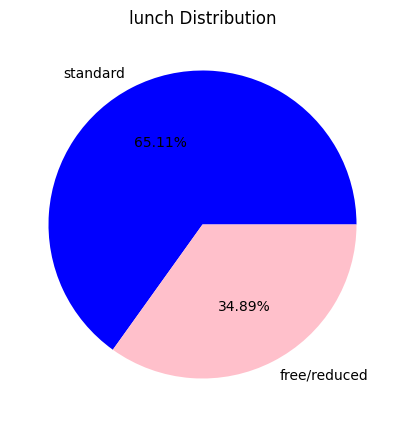

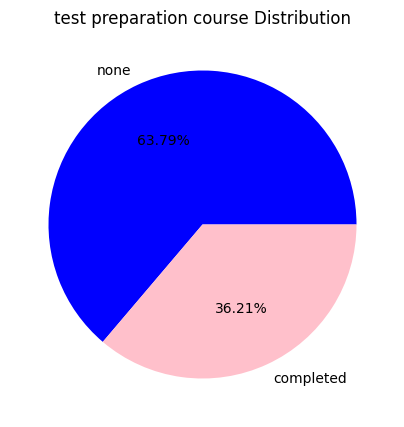

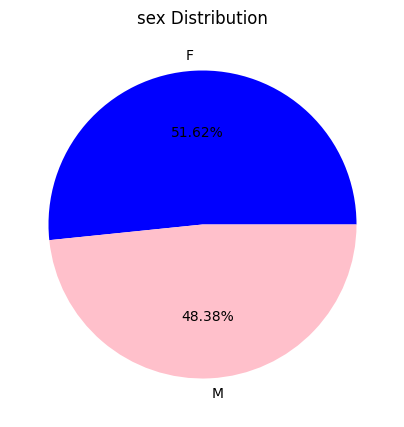

In [23]:

for i in data.columns:
    if data[i].dtype == 'object':
        plt.figure(figsize=(5,5))
        colors=["blue","pink", "purple","red","orange"]
        data[i].value_counts().plot.pie(colors=colors,autopct='%.2f%%' )
        plt.title(f"{i} Distribution")
        plt.ylabel('')
        plt.show()

In [24]:
'''categorical_cols = ['race/ethnicity', 'sex', 'lunch', 'parental level of education']
for col in categorical_cols:
    data[col] = LabelEncoder().fit_transform(data[col])
'''
encoders = {}

categorical_cols = ['race/ethnicity', 'sex', 'lunch', 'parental level of education']

for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    encoders[col] = le

for col in categorical_cols:
    print("Column:", col)
    for i, label in enumerate(encoders[col].classes_):
        print(label, "=", i)
    print("-"*40)


Column: race/ethnicity
group A = 0
group B = 1
group C = 2
group D = 3
group E = 4
----------------------------------------
Column: sex
F = 0
M = 1
----------------------------------------
Column: lunch
free/reduced = 0
standard = 1
----------------------------------------
Column: parental level of education
associate's degree = 0
bachelor's degree = 1
high school = 2
master's degree = 3
some college = 4
some high school = 5
----------------------------------------


In [25]:
data["Outcome"] = ((data["math percentage"] + data["reading score percentage"] + data["writing score percentage"]) / 3).apply(lambda x: 1 if x >= 0.5 else 0) #pass 1 fail 0

X = data.drop(columns=['Outcome', 'math percentage', 'reading score percentage', 'writing score percentage', 'test preparation course'])
y = data['Outcome']
X = X.fillna(X.median())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = metrics.accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

patient = {
    "race/ethnicity": 1,
    "parental level of education": 2,
    "lunch": 1,
    "sex": 0,
}
patient_df = pd.DataFrame(patient, index=[0])
y_pred_patient = model.predict(patient_df)[0]
print("Predicted Outcome for new data:", "Pass" if y_pred_patient == 1 else "Fail")

Model Accuracy: 90.91%
Predicted Outcome for new data: Pass


In [26]:
data["target"] = data["math percentage"].apply(lambda x: 1 if x >= 0.6 else 0)

X = data.drop(columns=["math percentage", "target"])
y = data["target"]

cols = X.select_dtypes(include=["object","string"]).columns

for col in cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy: {:.2f}%".format(accuracy*100))

Accuracy: 84.85%
